In [18]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import joblib

## 1) File paths and class map

In [3]:
DATA_DIR = Path("../data/raw")

FILES = {
    "rest/rest_stressed_20260406_170652.csv": "rest",
    "rest/rest_20260417_152340.csv": "rest",
    "rest/rest_20260417_152938.csv": "rest",
    "moderate/moderate_walking_20260407_120447.csv": "moderate",
    "moderate/moderate_walking_20260417_150822.csv": "moderate",
    "moderate/moderate_walking_20260417_151525.csv": "moderate",
    "moderate/moderate_stairs_20260411_224148.csv": "moderate",
    "moderate/moderate_stairs_20260417_163918.csv": "moderate",
    "moderate/moderate_stairs_20260417_164326.csv": "moderate",
    "intense/intense_running_20260414_195242.csv": "intense",
    "intense/intense_running_20260417_162157.csv": "intense",
    "intense/intense_running_20260417_160438.csv": "intense",
    "intense/intense_squats_20260411_223205.csv": "intense",
    "intense/intense_squats_20260417_153856.csv": "intense",
    "intense/intense_squats_20260417_154922.csv": "intense",
}

LABEL_MAP = {
    "rest": 0,
    "moderate": 1,
    "intense": 2
}


## 2) Load and clean each file

In [4]:
def load_and_clean_csv(file_path, class_label):
    df = pd.read_csv(file_path)

    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df = df.sort_values("timestamp").reset_index(drop=True)

    df["activity"] = class_label

    numeric_cols = ["temp", "emg_raw", "emg_env", "emg_state", "ax", "ay", "az", "hr"]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df.loc[df["hr"] <= 0, "hr"] = np.nan

    df["hr"] = df["hr"].interpolate(limit_direction="both")
    df["hr"] = df["hr"].ffill().bfill()

    for col in numeric_cols:
        df[col] = df[col].interpolate(limit_direction="both")
        df[col] = df[col].ffill().bfill()

    df["acc_mag"] = np.sqrt(df["ax"]**2 + df["ay"]**2 + df["az"]**2)

    df["dt"] = df["timestamp"].diff().dt.total_seconds()
    median_dt = df["dt"].median()
    df["dt"] = df["dt"].fillna(median_dt if pd.notna(median_dt) else 1.0)

    return df

## 3) Load all files

In [5]:
all_dfs = []

for fname, cls in FILES.items():
    path = DATA_DIR / fname
    print(path)
    df = load_and_clean_csv(path, cls)
    df["source_file"] = fname
    all_dfs.append(df)

full_df = pd.concat(all_dfs, ignore_index=True)

print(full_df.shape)
print(full_df[["source_file", "activity"]].drop_duplicates())
full_df.head()

..\data\raw\rest\rest_stressed_20260406_170652.csv
..\data\raw\rest\rest_20260417_152340.csv
..\data\raw\rest\rest_20260417_152938.csv
..\data\raw\moderate\moderate_walking_20260407_120447.csv
..\data\raw\moderate\moderate_walking_20260417_150822.csv
..\data\raw\moderate\moderate_walking_20260417_151525.csv
..\data\raw\moderate\moderate_stairs_20260411_224148.csv
..\data\raw\moderate\moderate_stairs_20260417_163918.csv
..\data\raw\moderate\moderate_stairs_20260417_164326.csv
..\data\raw\intense\intense_running_20260414_195242.csv
..\data\raw\intense\intense_running_20260417_162157.csv
..\data\raw\intense\intense_running_20260417_160438.csv
..\data\raw\intense\intense_squats_20260411_223205.csv
..\data\raw\intense\intense_squats_20260417_153856.csv
..\data\raw\intense\intense_squats_20260417_154922.csv
(3630, 14)
                                        source_file  activity
0            rest/rest_stressed_20260406_170652.csv      rest
331                   rest/rest_20260417_152340.csv 

,timestamp,label,temp,emg_raw,emg_env,emg_state,ax,ay,az,hr,activity,acc_mag,dt,source_file
0,2026-04-06 17:07:15.063368,rest,29.87,47.0,14.0,0.0,16884.0,-524.0,720.0,106.0,rest,16907.466753,1.035213,rest/rest_stressed_20260406_170652.csv
1,2026-04-06 17:07:16.098730,rest,29.87,69.0,16.0,1.0,16952.0,-460.0,744.0,106.0,rest,16974.552719,1.035362,rest/rest_stressed_20260406_170652.csv
2,2026-04-06 17:07:17.132831,rest,29.87,53.0,15.0,0.0,16916.0,-436.0,692.0,105.0,rest,16935.761453,1.034101,rest/rest_stressed_20260406_170652.csv
3,2026-04-06 17:07:18.168232,rest,29.87,62.0,13.0,0.0,16872.0,-492.0,636.0,103.0,rest,16891.149872,1.035401,rest/rest_stressed_20260406_170652.csv
4,2026-04-06 17:07:19.202292,rest,29.94,55.0,14.0,0.0,16956.0,-508.0,700.0,101.0,rest,16978.044646,1.034060,rest/rest_stressed_20260406_170652.csv


## 4) Window feature extraction

In [6]:
WINDOW_SEC = 10
STEP_SEC = 5

def waveform_length(x):
    x = np.asarray(x)
    if len(x) < 2:
        return 0.0
    return np.sum(np.abs(np.diff(x)))

def zero_crossings(x):
    x = np.asarray(x)
    if len(x) < 2:
        return 0
    x_centered = x - np.mean(x)
    return np.sum(np.diff(np.sign(x_centered)) != 0)

def slope_feature(x):
    x = np.asarray(x)
    if len(x) < 2:
        return 0.0
    return (x[-1] - x[0]) / len(x)

def extract_features_from_window(win):
    feats = {}

    # HR
    feats["hr_mean"] = win["hr"].mean()
    feats["hr_std"] = win["hr"].std()
    feats["hr_min"] = win["hr"].min()
    feats["hr_max"] = win["hr"].max()
    feats["hr_range"] = feats["hr_max"] - feats["hr_min"]

    # Temperature
    feats["temp_mean"] = win["temp"].mean()
    feats["temp_std"] = win["temp"].std()
    feats["temp_min"] = win["temp"].min()
    feats["temp_max"] = win["temp"].max()
    feats["temp_slope"] = slope_feature(win["temp"].values)

    # EMG
    feats["emg_raw_mean"] = win["emg_raw"].mean()
    feats["emg_raw_std"] = win["emg_raw"].std()
    feats["emg_env_mean"] = win["emg_env"].mean()
    feats["emg_env_std"] = win["emg_env"].std()
    feats["emg_rms"] = np.sqrt(np.mean(win["emg_raw"].values**2))
    feats["emg_mav"] = np.mean(np.abs(win["emg_raw"].values))
    feats["emg_wl"] = waveform_length(win["emg_raw"].values)
    feats["emg_zero_cross"] = zero_crossings(win["emg_raw"].values)
    feats["emg_state_mean"] = win["emg_state"].mean()

    # IMU axis stats
    for axis in ["ax", "ay", "az"]:
        feats[f"{axis}_mean"] = win[axis].mean()
        feats[f"{axis}_std"] = win[axis].std()
        feats[f"{axis}_min"] = win[axis].min()
        feats[f"{axis}_max"] = win[axis].max()

    # Magnitude stats
    feats["acc_mag_mean"] = win["acc_mag"].mean()
    feats["acc_mag_std"] = win["acc_mag"].std()
    feats["acc_mag_min"] = win["acc_mag"].min()
    feats["acc_mag_max"] = win["acc_mag"].max()
    feats["acc_mag_range"] = feats["acc_mag_max"] - feats["acc_mag_min"]
    feats["acc_mag_energy"] = np.mean(win["acc_mag"].values**2)

    # Jerk from magnitude
    if len(win) > 1:
        jerk = np.diff(win["acc_mag"].values)
        feats["jerk_mean"] = np.mean(np.abs(jerk))
        feats["jerk_std"] = np.std(jerk)
    else:
        feats["jerk_mean"] = 0.0
        feats["jerk_std"] = 0.0

    return feats

In [7]:
def build_windowed_dataset(df, window_sec=10, step_sec=5):
    rows = []

    for source_file, g in df.groupby("source_file"):
        g = g.sort_values("timestamp").reset_index(drop=True)

        start_time = g["timestamp"].min()
        end_time = g["timestamp"].max()

        t = start_time
        while t + pd.Timedelta(seconds=window_sec) <= end_time:
            w_end = t + pd.Timedelta(seconds=window_sec)
            win = g[(g["timestamp"] >= t) & (g["timestamp"] < w_end)].copy()

            # Require enough points
            if len(win) >= max(5, window_sec // 2):
                feats = extract_features_from_window(win)
                feats["label_name"] = win["activity"].iloc[0]
                feats["label"] = LABEL_MAP[win["activity"].iloc[0]]
                feats["source_file"] = source_file
                feats["window_start"] = t
                feats["window_end"] = w_end
                feats["n_samples"] = len(win)
                rows.append(feats)

            t += pd.Timedelta(seconds=step_sec)

    return pd.DataFrame(rows)

In [8]:
features_df = build_windowed_dataset(full_df, window_sec=WINDOW_SEC, step_sec=STEP_SEC)

print(features_df.shape)
print(features_df["label_name"].value_counts())
features_df.head()

(726, 45)
label_name
moderate    294
intense     244
rest        188
Name: count, dtype: int64


,hr_mean,hr_std,hr_min,hr_max,hr_range,temp_mean,temp_std,temp_min,temp_max,temp_slope,...,acc_mag_range,acc_mag_energy,jerk_mean,jerk_std,label_name,label,source_file,window_start,window_end,n_samples
0,97.300000,2.213594,94.0,101.0,7.0,27.723000,0.102746,27.56,27.87,-0.031000,...,2041.468517,3.373528e+08,614.065686,866.594422,intense,2,intense/intense_running_20260414_195242.csv,2026-04-14 19:53:17.519406,2026-04-14 19:53:27.519406,10
1,100.400000,3.893014,94.0,106.0,12.0,27.549000,0.117327,27.31,27.69,-0.038000,...,17123.972411,3.851633e+08,6623.889893,9265.482858,intense,2,intense/intense_running_20260414_195242.csv,2026-04-14 19:53:22.519406,2026-04-14 19:53:32.519406,10
2,105.900000,2.998148,101.0,109.0,8.0,27.275000,0.224314,26.94,27.56,-0.062000,...,17747.568929,3.820010e+08,11053.029205,11543.581328,intense,2,intense/intense_running_20260414_195242.csv,2026-04-14 19:53:27.519406,2026-04-14 19:53:37.519406,10
3,107.000000,1.632993,105.0,109.0,4.0,26.906000,0.225152,26.56,27.25,-0.069000,...,22243.470463,4.459598e+08,11270.565983,11857.971996,intense,2,intense/intense_running_20260414_195242.csv,2026-04-14 19:53:32.519406,2026-04-14 19:53:42.519406,10
4,107.888889,3.551213,105.0,114.0,9.0,26.582222,0.195114,26.31,26.87,-0.062222,...,21984.351951,5.460429e+08,13962.586061,14692.866503,intense,2,intense/intense_running_20260414_195242.csv,2026-04-14 19:53:37.519406,2026-04-14 19:53:47.519406,9


## 5) Prepare X and y

In [9]:
drop_cols = ["label_name", "label", "source_file", "window_start", "window_end"]
X = features_df.drop(columns=drop_cols)
y = features_df["label"]

# Fill any std NaNs caused by tiny windows
X = X.fillna(0)

print(X.shape)
print(y.value_counts())

(726, 40)
label
1    294
2    244
0    188
Name: count, dtype: int64


## 6) Train/test split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(544, 40) (182, 40)


## 7) Train Random Forest

In [11]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=["rest", "moderate", "intense"]
))

Accuracy: 0.9835164835164835

Classification Report:

              precision    recall  f1-score   support

        rest       1.00      1.00      1.00        47
    moderate       0.97      0.99      0.98        74
     intense       0.98      0.97      0.98        61

    accuracy                           0.98       182
   macro avg       0.99      0.98      0.99       182
weighted avg       0.98      0.98      0.98       182



## 7b) Train SVM Benchmark

In [19]:
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced",
        random_state=42
    ))
])

svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nSVM Classification Report:\n")
print(classification_report(
    y_test,
    y_pred_svm,
    target_names=["rest", "moderate", "intense"]
))

SVM Accuracy: 0.9945054945054945

SVM Classification Report:

              precision    recall  f1-score   support

        rest       1.00      1.00      1.00        47
    moderate       0.99      1.00      0.99        74
     intense       1.00      0.98      0.99        61

    accuracy                           0.99       182
   macro avg       1.00      0.99      1.00       182
weighted avg       0.99      0.99      0.99       182



## 8) Confusion matrix

[[47  0  0]
 [ 0 73  1]
 [ 0  2 59]]


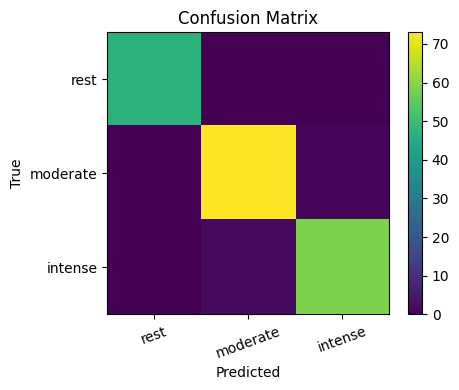

In [17]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1, 2], ["rest", "moderate", "intense"], rotation=20)
plt.yticks([0, 1, 2], ["rest", "moderate", "intense"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig("../data/processed/chart_baseline_confusion_matrix.png", dpi=300)
plt.show()

## 8b) SVM Confusion Matrix

[[47  0  0]
 [ 0 74  0]
 [ 0  1 60]]


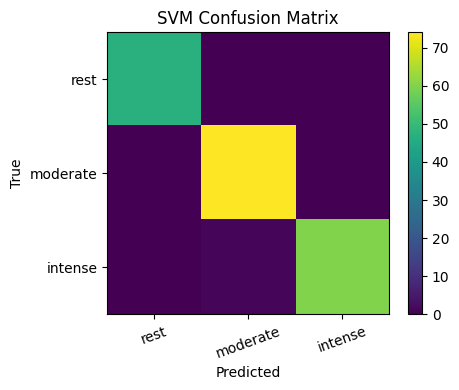

In [20]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
print(cm_svm)

plt.figure(figsize=(5, 4))
plt.imshow(cm_svm, interpolation="nearest")
plt.title("SVM Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1, 2], ["rest", "moderate", "intense"], rotation=20)
plt.yticks([0, 1, 2], ["rest", "moderate", "intense"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig("../data/processed/chart_baseline_svm_confusion_matrix.png", dpi=300)
plt.show()

## 9) Feature importance

jerk_std         0.093720
jerk_mean        0.093587
acc_mag_std      0.077786
ax_std           0.064450
az_std           0.063439
acc_mag_range    0.057563
acc_mag_min      0.056056
emg_env_mean     0.041862
ay_max           0.037417
ay_std           0.033947
emg_rms          0.031808
emg_mav          0.030245
temp_mean        0.028826
temp_min         0.027653
emg_raw_mean     0.025024
hr_max           0.022737
temp_max         0.022704
acc_mag_max      0.019817
hr_mean          0.019421
ay_min           0.018364
dtype: float64


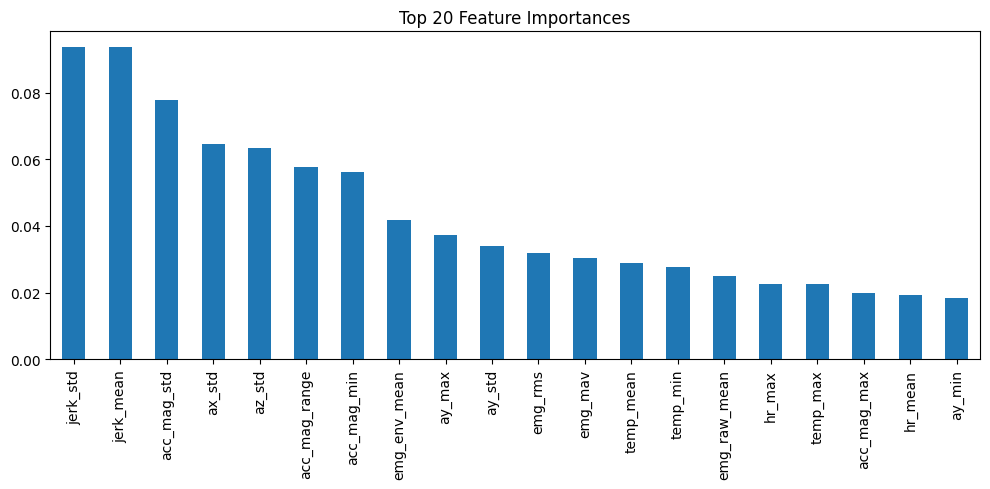

In [16]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print(importances.head(20))

plt.figure(figsize=(10, 5))
importances.head(20).plot(kind="bar")
plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.savefig("../data/processed/baseline_chart_top_feature_importance.png", dpi=300)
plt.show()

## 10) Save outputs

In [14]:
from pathlib import Path
import joblib

Path("../data/processed").mkdir(parents=True, exist_ok=True)
Path("../models/classical").mkdir(parents=True, exist_ok=True)

features_df.to_csv("../data/processed/activity_fusion_features_sensors_multiplefiles.csv", index=False)
joblib.dump(rf, "../models/classical/activity_classifier_rf_sensors_multiplefiles.pkl")

print("Saved successfully.")

Saved successfully.


## Summary text File

In [22]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd

rf_acc = accuracy_score(y_test, y_pred)
svm_acc = accuracy_score(y_test, y_pred_svm)

with open("../data/processed/baseline_metrics_summary.txt", "w", encoding="utf-8") as f:
    f.write("Baseline Evaluation Results (Random Train/Test Split)\n")
    f.write("=" * 60)

    f.write("\n\nRandom Forest Accuracy:\n")
    f.write(str(rf_acc))

    f.write("\n\nRandom Forest Classification Report:\n")
    f.write(classification_report(
        y_test,
        y_pred,
        target_names=["rest", "moderate", "intense"]
    ))

    rf_cm = confusion_matrix(y_test, y_pred)
    f.write("\nRandom Forest Confusion Matrix:\n")
    f.write(pd.DataFrame(
        rf_cm,
        index=["true_rest", "true_moderate", "true_intense"],
        columns=["pred_rest", "pred_moderate", "pred_intense"]
    ).to_string())

    f.write("\n\nSVM Accuracy:\n")
    f.write(str(svm_acc))

    f.write("\n\nSVM Classification Report:\n")
    f.write(classification_report(
        y_test,
        y_pred_svm,
        target_names=["rest", "moderate", "intense"]
    ))

    svm_cm = confusion_matrix(y_test, y_pred_svm)
    f.write("\nSVM Confusion Matrix:\n")
    f.write(pd.DataFrame(
        svm_cm,
        index=["true_rest", "true_moderate", "true_intense"],
        columns=["pred_rest", "pred_moderate", "pred_intense"]
    ).to_string())

    f.write("\n\nTest Set Size:\n")
    f.write(str(len(y_test)))

print("Saved baseline metrics summary.")

Saved baseline metrics summary.


## Baseline RF vs SVM Comparison

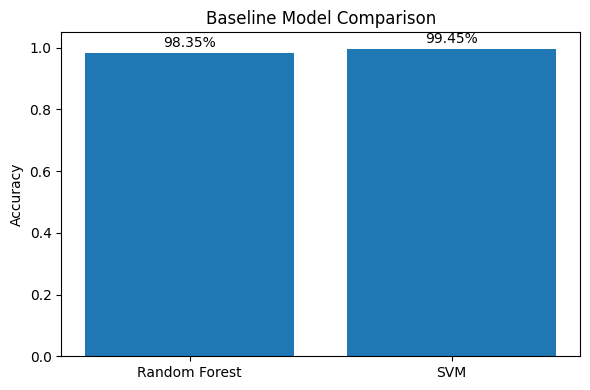

In [21]:
rf_acc = accuracy_score(y_test, y_pred)
svm_acc = accuracy_score(y_test, y_pred_svm)

plt.figure(figsize=(6, 4))
bars = plt.bar(["Random Forest", "SVM"], [rf_acc, svm_acc])
plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.title("Baseline Model Comparison")

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 0.02, f"{h:.2%}", ha="center")

plt.tight_layout()
plt.savefig("../data/processed/chart_baseline_rf_vs_svm.png", dpi=300)
plt.show()

## Table summary for charting

In [23]:

# RF metrics
rf_report = classification_report(y_test, y_pred, output_dict=True)
rf_acc = accuracy_score(y_test, y_pred)

# SVM metrics
svm_report = classification_report(y_test, y_pred_svm, output_dict=True)
svm_acc = accuracy_score(y_test, y_pred_svm)

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1"],
    "Random Forest": [
        rf_acc,
        rf_report["macro avg"]["precision"],
        rf_report["macro avg"]["recall"],
        rf_report["macro avg"]["f1-score"]
    ],
    "SVM": [
        svm_acc,
        svm_report["macro avg"]["precision"],
        svm_report["macro avg"]["recall"],
        svm_report["macro avg"]["f1-score"]
    ]
})

metrics_df

,Metric,Random Forest,SVM
0,Accuracy,0.983516,0.994505
1,Precision,0.985556,0.995556
2,Recall,0.984567,0.994536
3,F1,0.985024,0.995008


## Plot baseline metrics comparison chart

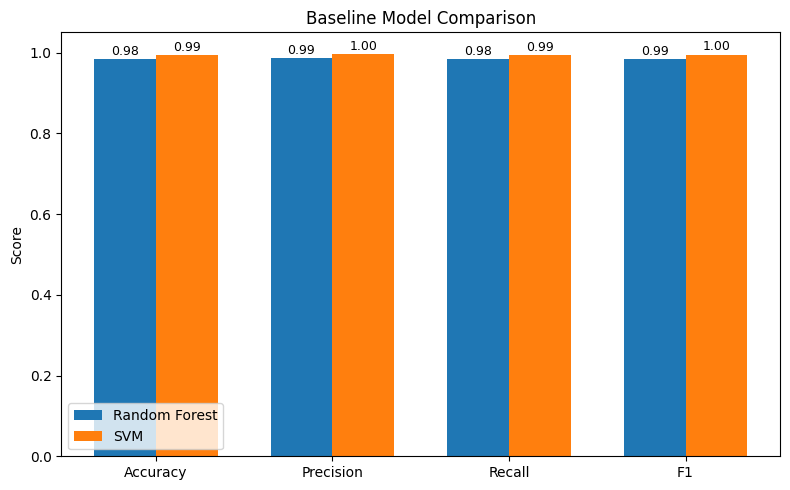

In [24]:
# Plot baseline chart
x = np.arange(len(metrics_df["Metric"]))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, metrics_df["Random Forest"], width, label="Random Forest")
plt.bar(x + width/2, metrics_df["SVM"], width, label="SVM")

plt.xticks(x, metrics_df["Metric"])
plt.ylim(0,1.05)
plt.ylabel("Score")
plt.title("Baseline Model Comparison")
plt.legend()

for i, v in enumerate(metrics_df["Random Forest"]):
    plt.text(i - width/2, v + 0.01, f"{v:.2f}", ha="center", fontsize=9)

for i, v in enumerate(metrics_df["SVM"]):
    plt.text(i + width/2, v + 0.01, f"{v:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("../data/processed/chart_baseline_metrics_rf_vs_svm.png", dpi=300)
plt.show()